In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
from io import StringIO

classes = pd.read_csv('class.tsv', sep='\t', header=None)
labels = classes[0].values

with gzip.open('columns.tsv.gz', 'rt') as f:
    lines = [line for line in f if not line.startswith('#')]
col_data = pd.read_csv(StringIO(''.join(lines)), sep='\t')

with gzip.open('filtered.tsv.gz', 'rt') as f:
    data = pd.read_csv(f, sep='\t', index_col=0)
data.columns = data.columns.astype(str).str.strip()

In [14]:
xbp1_id = 4404
gata3_id = col_data[col_data['GeneSymbol'] == 'GATA3']['ID'].values[0]

xbp1 = data[str(xbp1_id)].values
gata3 = data[str(gata3_id)].values
X = np.column_stack((gata3, xbp1))

colors = ['red' if label == 1 else 'black' for label in labels]

print(f"GATA3 ID: {gata3_id}, XBP1 ID: {xbp1_id}")

GATA3 ID: 4359, XBP1 ID: 4404


In [15]:
def pca(X):
    X_centered = X - np.mean(X, axis=0)
    cov = np.cov(X_centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    return eigvecs[:, idx], eigvals[idx], X_centered

vectors, values, X_centered = pca(X)
pc1, pc2 = vectors[:, 0], vectors[:, 1]
pc1_proj = np.dot(X_centered, pc1)
pc2_proj = np.dot(X_centered, pc2)

if np.mean(pc1_proj[labels == 1]) < np.mean(pc1_proj[labels == 0]):
    pc1, pc1_proj = -pc1, -pc1_proj

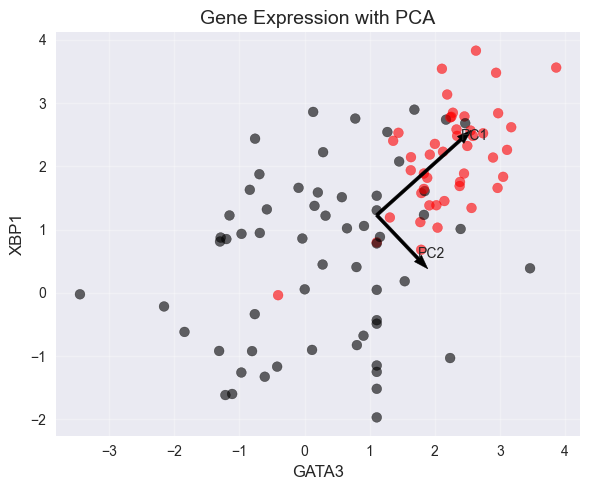

In [16]:
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(6, 5))
plt.scatter(gata3, xbp1, c=colors, alpha=0.6, s=50)
plt.xlabel('GATA3', fontsize=12)
plt.ylabel('XBP1', fontsize=12)
plt.title('Gene Expression with PCA', fontsize=14)

mean_g, mean_x = np.mean(gata3), np.mean(xbp1)
scale1, scale2 = np.sqrt(values[0]), np.sqrt(values[1])
plt.arrow(mean_g, mean_x, pc1[0]*scale1, pc1[1]*scale1, color='black', width=0.05)
plt.arrow(mean_g, mean_x, pc2[0]*scale2, pc2[1]*scale2, color='black', width=0.05)
plt.text(mean_g + pc1[0]*scale1, mean_x + pc1[1]*scale1, 'PC1', fontsize=10)
plt.text(mean_g + pc2[0]*scale2, mean_x + pc2[1]*scale2, 'PC2', fontsize=10)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

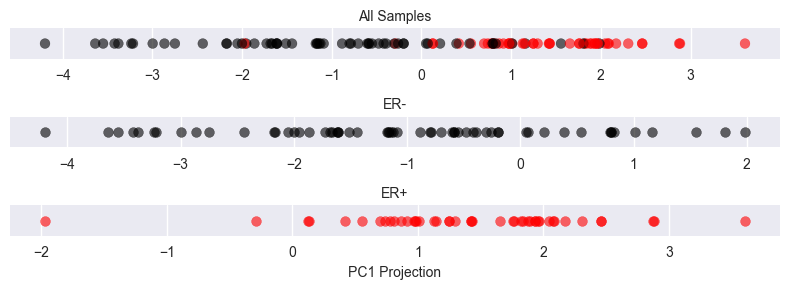

In [17]:
plt.figure(figsize=(8, 3))
plt.style.use('seaborn-v0_8')

plt.subplot(3, 1, 1)
plt.scatter(pc1_proj, np.zeros_like(pc1_proj), c=colors, alpha=0.6, s=50)
plt.title('All Samples', fontsize=10)
plt.yticks([])

plt.subplot(3, 1, 2)
plt.scatter(pc1_proj[labels == 0], np.zeros_like(pc1_proj[labels == 0]), c='black', alpha=0.6, s=50)
plt.title('ER-', fontsize=10)
plt.yticks([])

plt.subplot(3, 1, 3)
plt.scatter(pc1_proj[labels == 1], np.zeros_like(pc1_proj[labels == 1]), c='red', alpha=0.6, s=50)
plt.title('ER+', fontsize=10)
plt.yticks([])
plt.xlabel('PC1 Projection', fontsize=10)

plt.tight_layout()
plt.show()

PC1 Variance: 0.7792
PC2 Variance: 0.2208


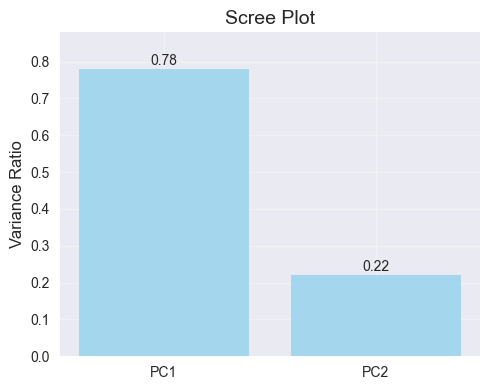

In [18]:
var_ratio = values / np.sum(values)
print(f"PC1 Variance: {var_ratio[0]:.4f}")
print(f"PC2 Variance: {var_ratio[1]:.4f}")

plt.figure(figsize=(5, 4))
plt.bar(['PC1', 'PC2'], var_ratio, color='skyblue', alpha=0.7)
for i, v in enumerate(var_ratio):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)
plt.ylabel('Variance Ratio', fontsize=12)
plt.title('Scree Plot', fontsize=14)
plt.ylim(0, max(var_ratio) + 0.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()